In [1]:
#reading file 
import pandas as pd
with open('EV_sales.csv') as E:
    ev=pd.read_csv(E)
ev

,RecordID,Year,State,Manufacturer,VehicleType,EVSales,BatteryCapacity
0,1,2021,Andhra Pradesh,BYD,Electric Scooter,2106,30
1,2,2022,Gujarat,Tata,Electric Bike,4567,13
2,3,2025,Tamil Nadu,Tata,Electric Car,867,29
3,4,2022,Maharashtra,Mahindra,Electric Car,4697,27
4,5,2025,Tamil Nadu,Ola,Electric Scooter,4927,37
...,...,...,...,...,...,...,...
145,146,2021,Andhra Pradesh,MG,Electric Scooter,706,75
146,147,2021,Telangana,Ola,Electric Bike,2589,12
147,148,2022,Andhra Pradesh,Mahindra,Electric Scooter,4983,30
148,149,2025,Tamil Nadu,MG,Electric Scooter,2535,56


### Data Visualization
38. How has EV sales changed over the years? => Line Chart
39. Which manufacturer contributes the highest EV sales? => Bar Char
40. Which states have the highest and lowest EV sales?=>Horizontal Bar Chart
41. What is the distribution of vehicle types in the dataset? => Pie Chart
42. How are battery capacities distributed among EVs? => Histogram
43. Is there any relationship between battery capacity and EV sales? => Scatter Plot

In [3]:
import matplotlib.pyplot as plt



In [4]:
#38. How has EV sales changed over the years? => Line Chart
sales_yearly=ev.groupby("Year")["EVSales"].sum().reset_index()


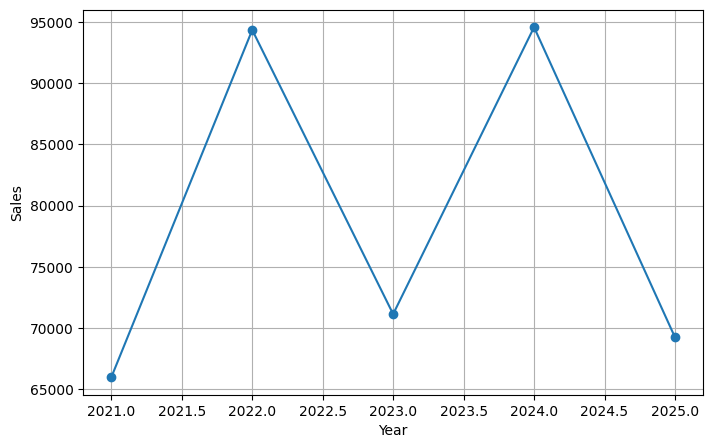

In [5]:
plt.figure(figsize=(8, 5))
plt.plot(sales_yearly["Year"],sales_yearly["EVSales"],marker='o',linestyle='-')
plt.xlabel("Year")
plt.ylabel("Sales")
plt.title("Sales Over The Years")
plt.grid(True)
plt.show()

In [7]:
#39. Which manufacturer contributes the highest EV sales? => Bar Char
highest_sales=ev.groupby("Manufacturer")["EVSales"].sum().reset_index()
highest_sales

,Manufacturer,EVSales
0,Ather,69996
1,BYD,70180
2,MG,48237
3,Mahindra,89843
4,Ola,63383
5,Tata,53688


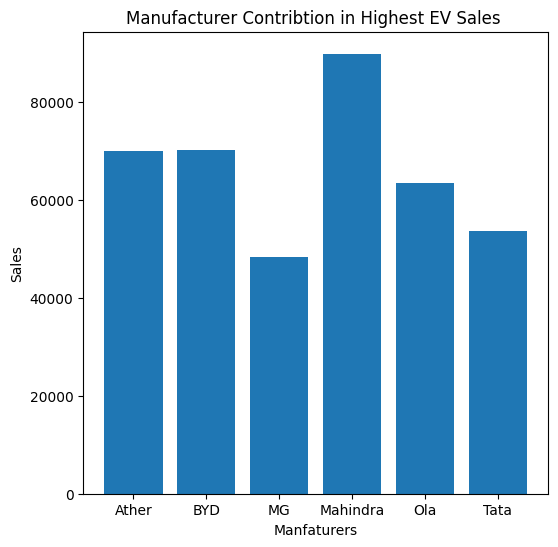

In [9]:
plt.figure(figsize=(6,6))
plt.bar(highest_sales["Manufacturer"],highest_sales["EVSales"])
plt.xlabel("Manfaturers")
plt.ylabel("Sales")
plt.title("Manufacturer Contribtion in Highest EV Sales ")
plt.show()

In [11]:
#40. Which states have the highest and lowest EV sales?=>Horizontal Bar Chart
state_sales=ev.groupby("State")["EVSales"].sum().reset_index()
state_sales

,State,EVSales
0,Andhra Pradesh,86896
1,Gujarat,70000
2,Karnataka,44011
3,Maharashtra,50455
4,Tamil Nadu,88012
5,Telangana,55953


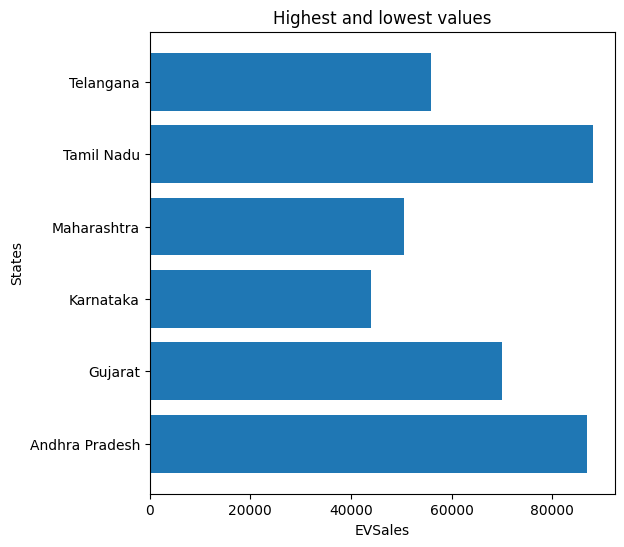

In [12]:
plt.figure(figsize=(6,6))
plt.barh(state_sales["State"],state_sales["EVSales"])
plt.ylabel("States")
plt.xlabel("EVSales")
plt.title("Highest and lowest values")
plt.show()

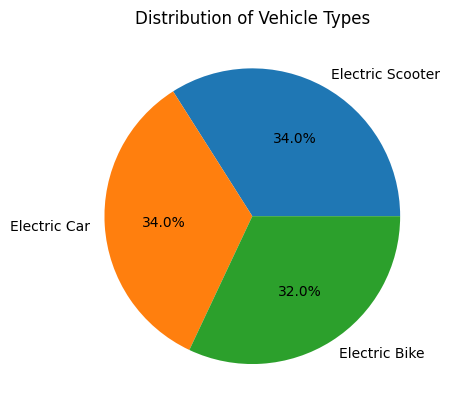

In [14]:
#41. What is the distribution of vehicle types in the dataset? => Pie Chart
vehicle_types=ev["VehicleType"].value_counts()
plt.pie(vehicle_types,
       labels=vehicle_types.index,
       autopct='%1.1f%%')
plt.title("Distribution of Vehicle Types")
plt.show()

In [15]:
#42. How are battery capacities distributed among EVs? => Histogram
battery_capacities=ev["BatteryCapacity"].value_counts().reset_index()
battery_capacities

,BatteryCapacity,count
0,32,7
1,29,6
2,37,6
3,30,5
4,35,5
5,57,4
6,22,4
7,72,4
8,63,4
9,44,4


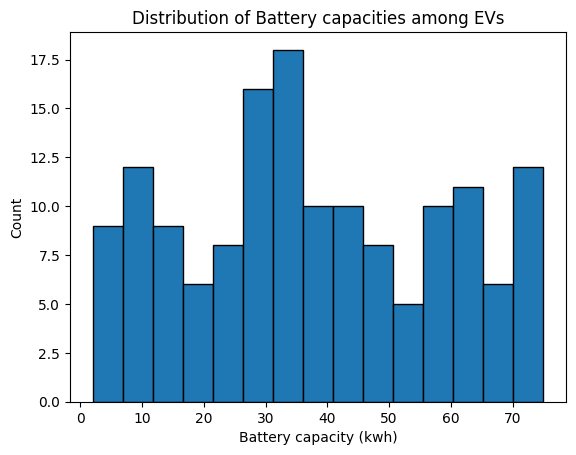

In [18]:
plt.hist(ev["BatteryCapacity"],bins=15,edgecolor="black"
        )
plt.xlabel("Battery capacity (kwh)")
plt.ylabel("Count")
plt.title("Distribution of Battery capacities among EVs")
plt.show()

### Seaborn
43. Is there any relationship between battery capacity and EV sales? => Scatter Plot
44. Which EV manufacturer has the highest number of vehicles? => count plot
45. How does electric range vary among different vehicle types? => box plot
46. What is the distribution of electric range in the dataset? => Histplot
47. Create a heatmap showing correlations between numerical columns.

In [20]:
#43. Is there any relationship between battery capacity and EV sales? => Scatter Plot
relation=ev.groupby("BatteryCapacity")["EVSales"].sum().reset_index()
relation

,BatteryCapacity,EVSales
0,2,6876
1,3,8961
2,4,11344
3,5,6004
4,7,5044
5,9,5233
6,10,8300
7,11,8003
8,12,5059
9,13,5083


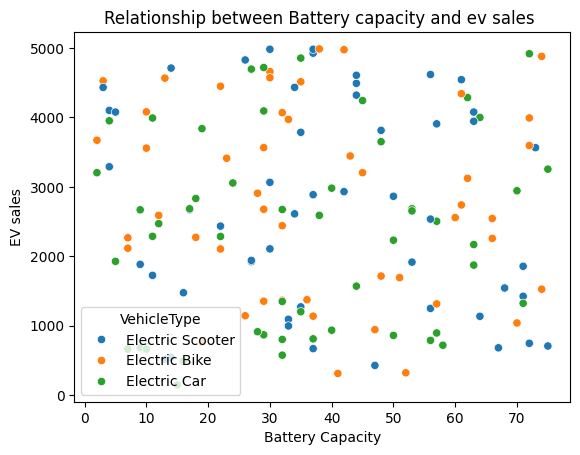

In [21]:
import seaborn as sns
sns.scatterplot(data=ev,
               x="BatteryCapacity",
               y="EVSales",
               hue="VehicleType"
               )
plt.xlabel("Battery Capacity")
plt.ylabel("EV sales")
plt.title("Relationship between Battery capacity and ev sales ")
plt.show()

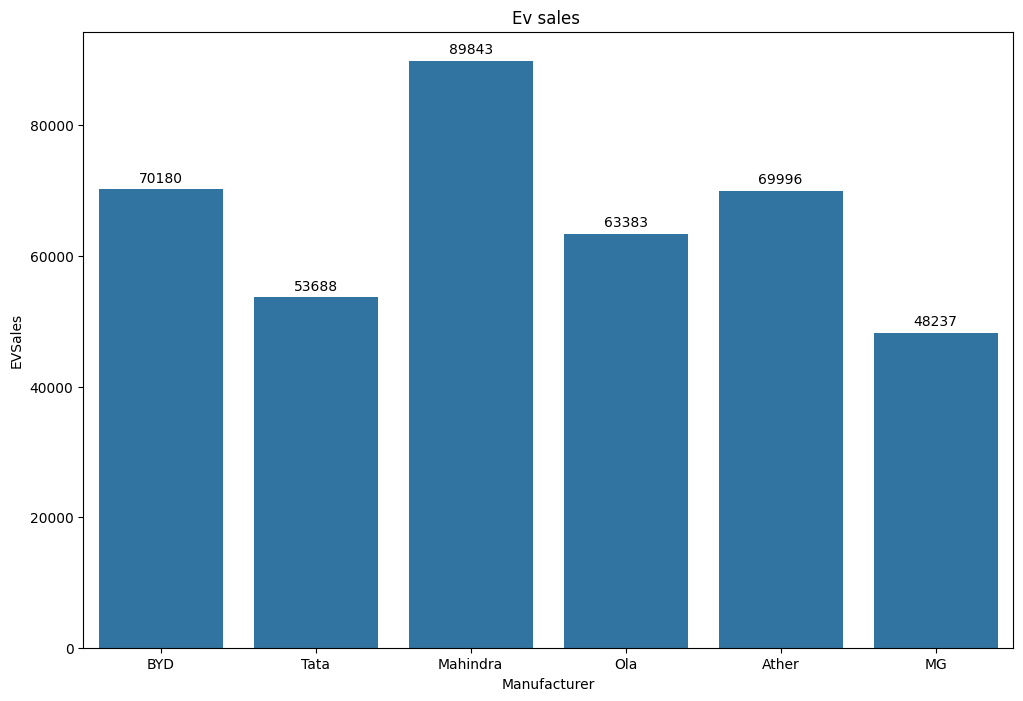

In [22]:
#44. Which EV manufacturer has the highest number of vehicles Sales? => barplot
plt.figure(figsize=(12,8))
ax =sns.barplot(data=ev,
             x="Manufacturer",
             y="EVSales",
           estimator=sum,
               errorbar=None)
ax.bar_label(ax.containers[0],
            fmt='%d',
            padding=3)
plt.title("Ev sales ")
plt.show()

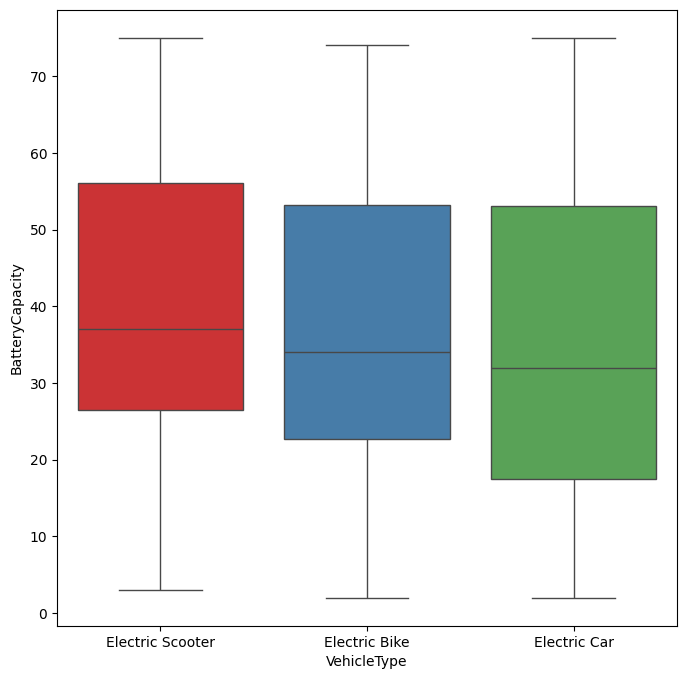

In [23]:
#45. How does battery capacity vary among different vehicle types? => box plot
plt.figure(figsize=(8,8))
ax=sns.boxplot(data=ev,
              x="VehicleType",
              y="BatteryCapacity",
               hue="VehicleType",
               legend=False,
              palette="Set1")
plt.show()

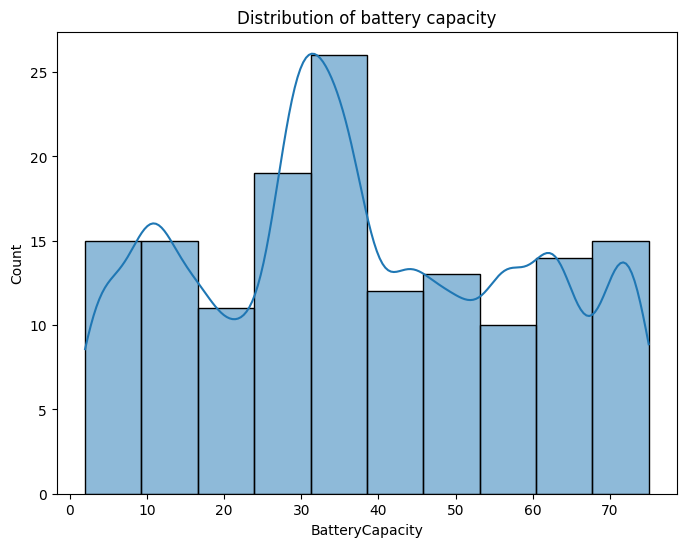

In [24]:
#46. What is the distribution of battery capacity in the dataset? => Histplot
plt.figure(figsize=(8,6))
sns.histplot(
    data=ev,
    x="BatteryCapacity",
    kde=True,
    bins=10,
    kde_kws={'bw_adjust':0.35}
)
plt.title("Distribution of battery capacity")
plt.show()


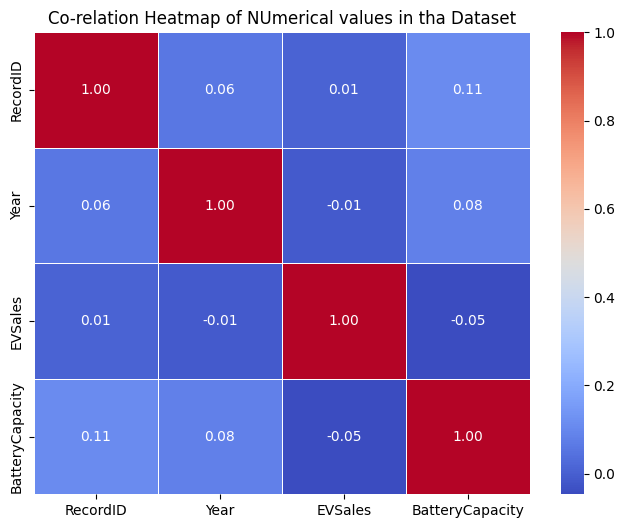

In [25]:
#47. Create a heatmap showing correlations between numerical columns.
plt.figure(figsize=(8,6))
x=ev.select_dtypes(include=["number"])
matrix=x.corr()

sns.heatmap(
    matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)
plt.title("Co-relation Heatmap of NUmerical values in tha Dataset")
plt.show()